# L08 · Training Deep Networks on Blood-Cell Images

*Companion notebook for Lecture 8 — Deep Learning in Practice (CS184A/284A, AI in Biology and Medicine).*

**Learning objectives**

1. Write a complete PyTorch training loop (mini-batches, `zero_grad` → `backward` → `step`, learning-rate schedule, `train()`/`eval()`, best-validation checkpoint) for the reference MLP on BloodMNIST.
2. Compare SGD, SGD + momentum and Adam, and sweep the learning rate η to recognize "too small", "good" and "too large".
3. See why initialization and normalization matter: zero initialization, BatchNorm vs LayerNorm vs none, and BatchNorm's train vs eval behavior.
4. Regularize with dropout, weight decay and early stopping, and read the train–validation gap from learning curves.
5. Make runs reproducible with seeds and measure the seed-to-seed spread before trusting a 1-point difference.

Every experiment is the one behind a slide in the deck (same data, split, seeds and settings; ported from `slides_src/lectures/L08_deep_learning_practice.py`). The small MLP trains in a few seconds per run, so the whole notebook uses the **full training set** and takes about 3 minutes on a laptop CPU (no GPU needed). The device (CUDA > MPS > CPU) is picked automatically.

In [1]:
import sys, pathlib, time, copy
sys.path.insert(0, str(pathlib.Path.cwd().parent))  # course_utils.py lives in applications/
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch import nn
from sklearn.metrics import f1_score, classification_report
from medmnist import BloodMNIST
from course_utils import seed_everything, plot_style, device, DATA, PALETTE

rng = seed_everything(0)
plot_style()
dev = device()
cpu = torch.device("cpu")
print("device:", dev, "| torch", torch.__version__)
T_START = time.time()

EPOCHS = 15      # reference recipe (shared with L09)
BATCH = 128
CLASSES = ["basophil", "eosinophil", "erythroblast", "immature gran.", "lymphocyte", "monocyte", "neutrophil", "platelet"]

device: cpu | torch 2.14.0+cu130


## 1. Dataset: white blood cells in peripheral blood smears

**Biological question.** Which type of blood cell is in this image? The *differential count* of white blood cell types is part of the routine complete blood count; shifts in the mix point to infection, allergy, parasites or blood cancers, and automated analyzers pre-classify cell images to speed up review.

- **What is measured:** a stained (May Grünwald–Giemsa) peripheral blood smear, imaged cell by cell with an automated microscope (CellaVision DM96).
- **One sample** = one image of one cell, $\mathbf X \in \mathbb R^{3\times 28\times 28}$; the MLP sees it flattened, $\mathbf x \in \mathbb R^{d}$ with $d = 2352$.
- **Target:** one of 8 classes (basophil, eosinophil, erythroblast, immature granulocytes, lymphocyte, monocyte, neutrophil, platelet).

**Source.** BloodMNIST from *MedMNIST v2* (Yang et al., *Scientific Data* 10, 41, 2023; **license CC BY 4.0**), built from Acevedo et al., *Data in Brief* 30, 105474 (2020): 17,092 images of normal blood cells from the Hospital Clinic of Barcelona, resized to 28 × 28 by MedMNIST. We use the official train/validation/test split. The files (35 MB) are cached in `applications/data/`. This is the same data and model as L09, which then replaces the MLP by a CNN.

In [2]:
def load(split):
    ds = BloodMNIST(split=split, download=True, root=str(DATA))
    x = torch.tensor(ds.imgs).permute(0, 3, 1, 2).float() / 255   # N x H x W x C  ->  N x C x H x W, in [0, 1]
    return x, torch.tensor(ds.labels[:, 0]).long()

raw = {s: load(s) for s in ["train", "val", "test"]}
for s, (x, y) in raw.items():
    print(f"{s:5s} {tuple(x.shape)}")

train (11959, 3, 28, 28)
val   (1712, 3, 28, 28)
test  (3421, 3, 28, 28)


## 2. Exploration: class balance

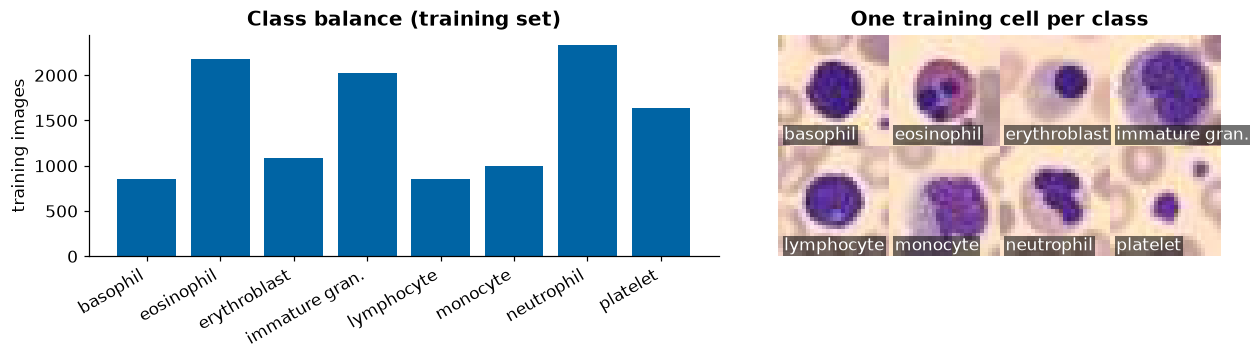

majority class: neutrophil (19.5% of training cells)


In [3]:
y_tr_raw = raw["train"][1].numpy()
counts = np.bincount(y_tr_raw, minlength=8)
fig, axes = plt.subplots(1, 2, figsize=(12, 3.4), gridspec_kw=dict(width_ratios=[1.2, 1]))
axes[0].bar(CLASSES, counts, color=PALETTE[0])
axes[0].set(ylabel="training images", title="Class balance (training set)")
axes[0].tick_params(axis="x", rotation=30)
for lab in axes[0].get_xticklabels():
    lab.set_ha("right")
tiles = [raw["train"][0][np.where(y_tr_raw == c)[0][0]] for c in range(8)]
axes[1].imshow(torch.cat([torch.cat(tiles[:4], 2), torch.cat(tiles[4:], 2)], 1).permute(1, 2, 0))
for c in range(8):
    axes[1].text(28 * (c % 4) + 1, 28 * (c // 4) + 26, CLASSES[c], fontsize=11, color="white",
                 bbox=dict(fc="black", alpha=0.55, lw=0, pad=1))
axes[1].axis("off"); axes[1].set_title("One training cell per class")
plt.tight_layout(); plt.show()
majority = counts.argmax()
print("majority class:", CLASSES[majority], f"({100 * counts[majority] / counts.sum():.1f}% of training cells)")

The classes are imbalanced, so besides accuracy we report **macro-F1**. A model that ignores the input and always predicts the majority class (neutrophil) is the floor every model must beat — we will meet it again with zero initialization.

## 3. Preprocessing
Standardize each color channel with the **training-set** mean and standard deviation (never with validation/test statistics). With $n = 11{,}959$ training cells and $|B| = 128$ there are 94 mini-batch updates per epoch.

In [4]:
Xtr_raw = raw["train"][0]
mu, sd = Xtr_raw.mean((0, 2, 3), keepdim=True), Xtr_raw.std((0, 2, 3), keepdim=True)
std_data = {s: ((x - mu) / sd, y) for s, (x, y) in raw.items()}
X_tr, y_tr = std_data["train"]; X_va, y_va = std_data["val"]; X_te, y_te = std_data["test"]
steps_ep = int(np.ceil(len(X_tr) / BATCH))
print("channel means", mu.flatten().numpy().round(3), " SDs", sd.flatten().numpy().round(3))
print(f"n = {len(X_tr):,}, |B| = {BATCH} -> {steps_ep} steps per epoch, {EPOCHS * steps_ep:,} updates in {EPOCHS} epochs")

channel means [0.794 0.66  0.696]  SDs [0.216 0.242 0.118]
n = 11,959, |B| = 128 -> 94 steps per epoch, 1,410 updates in 15 epochs


## 4. Model: the reference MLP

Flatten → [Linear → normalization → ReLU → (dropout)] × 2 → Linear(8). The default is the L08/L09 baseline, **2352 → 40 → 40 → 8 with BatchNorm**: $2352\cdot 40 + 40 + 2\cdot 40 + 40\cdot 40 + 40 + 2\cdot 40 + 40\cdot 8 + 8 = 96{,}248$ parameters. The arguments let us switch the normalization (`"bn"`, `"ln"`, `None`), add dropout, or change the widths.

In [5]:
def mlp(widths=(40, 40), norm="bn", p_drop=0.0):
    layers, d_in = [nn.Flatten()], 3 * 28 * 28
    for w in widths:
        layers.append(nn.Linear(d_in, w))
        if norm == "bn":
            layers.append(nn.BatchNorm1d(w))
        elif norm == "ln":
            layers.append(nn.LayerNorm(w))
        layers.append(nn.ReLU())
        if p_drop:
            layers.append(nn.Dropout(p_drop))
        d_in = w
    layers.append(nn.Linear(d_in, 8))
    return nn.Sequential(*layers)

n_params = lambda m: sum(p.numel() for p in m.parameters())
print(mlp())
print(f"parameters: {n_params(mlp()):,}")

Sequential(
  (0): Flatten(start_dim=1, end_dim=-1)
  (1): Linear(in_features=2352, out_features=40, bias=True)
  (2): BatchNorm1d(40, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (3): ReLU()
  (4): Linear(in_features=40, out_features=40, bias=True)
  (5): BatchNorm1d(40, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (6): ReLU()
  (7): Linear(in_features=40, out_features=8, bias=True)
)
parameters: 96,248


## 5. Training loop

One function runs every experiment in this notebook. It mirrors the loop on the lecture's PyTorch slide:

- reshuffle every epoch (`torch.randperm`), cut into mini-batches of 128;
- `opt.zero_grad()` → forward → cross-entropy 𝓛 → `loss.backward()` → `opt.step()` → `sched.step()` (scheduler stepped every mini-batch);
- after each epoch, evaluate in `eval()` mode on the training and validation data (under `torch.no_grad()`), and keep the **best-validation checkpoint** — early stopping by model selection;
- stop and flag the run if the loss becomes non-finite (divergence);
- finally, evaluate the selected model **once** on the test set (accuracy and macro-F1).

The default is the reference recipe: Adam, one-cycle schedule peaking at η = 3·10⁻³, 15 epochs, batch 128, seed 0.

In [6]:
def evaluate(m, X, y, device, bs=2000):
    m.eval()
    loss, correct = 0.0, 0
    with torch.no_grad():
        for i in range(0, len(X), bs):
            out = m(X[i:i + bs].to(device)); yb = y[i:i + bs].to(device)
            loss += nn.functional.cross_entropy(out, yb, reduction="sum").item()
            correct += (out.argmax(1) == yb).sum().item()
    return loss / len(X), correct / len(X)

def train(model_kw=None, opt="adam", lr=1e-3, wd=0.0, momentum=0.9, sched="onecycle", max_lr=3e-3, epochs=EPOCHS,
          batch=BATCH, n_train=None, seed=0, keep_best=True, device=None, init=None):
    """Train an MLP on (a subset of) BloodMNIST; returns per-epoch histories, best epoch, test accuracy/macro-F1."""
    device = device or dev
    torch.manual_seed(seed)
    Xtr, ytr = X_tr, y_tr
    if n_train:                                   # random training subset (its own generator: same subset per seed)
        sub = torch.randperm(len(Xtr), generator=torch.Generator().manual_seed(1000 + seed))[:n_train]
        Xtr, ytr = Xtr[sub], ytr[sub]
    m = mlp(**(model_kw or {}))
    if init is not None:
        init(m)
    m = m.to(device)
    if opt == "sgd":
        o = torch.optim.SGD(m.parameters(), lr=lr, weight_decay=wd)
    elif opt == "momentum":
        o = torch.optim.SGD(m.parameters(), lr=lr, momentum=momentum, weight_decay=wd)
    elif opt == "adam":
        o = torch.optim.Adam(m.parameters(), lr=lr, weight_decay=wd)
    elif opt == "adamw":                          # decoupled weight decay
        o = torch.optim.AdamW(m.parameters(), lr=lr, weight_decay=wd)
    steps = int(np.ceil(len(Xtr) / batch))
    sch = (torch.optim.lr_scheduler.OneCycleLR(o, max_lr=max_lr, total_steps=epochs * steps)
           if sched == "onecycle" else None)
    Xd, yd = Xtr.to(device), ytr.to(device)
    h = {k: [] for k in ["train_loss", "train_acc", "train_eval_loss", "train_eval_acc", "val_loss", "val_acc",
                         "lr", "step_loss"]}
    best, best_state, t0 = -1, None, time.time()
    for ep in range(epochs):
        m.train()
        perm = torch.randperm(len(Xtr))
        tot, correct, n, bad = 0.0, 0, 0, False
        for i in range(0, len(Xtr), batch):
            idx = perm[i:i + batch].to(device)
            xb, yb = Xd[idx], yd[idx]
            o.zero_grad()
            logits = m(xb)
            loss = nn.functional.cross_entropy(logits, yb)
            lv = loss.item()
            if not np.isfinite(lv) or lv > 1e4:  # diverged
                bad = True
                break
            loss.backward()
            o.step()
            h["lr"].append(o.param_groups[0]["lr"])
            if sch:
                sch.step()
            h["step_loss"].append(lv)
            tot += lv * len(idx); correct += (logits.argmax(1) == yb).sum().item(); n += len(idx)
        if bad:
            h["diverged_epoch"] = ep + 1
            break
        h["train_loss"].append(tot / n); h["train_acc"].append(correct / n)   # running, train mode
        for k, (X, y) in [("train_eval", (Xtr, ytr)), ("val", (X_va, y_va))]:
            l_, a_ = evaluate(m, X, y, device)
            h[f"{k}_loss"].append(l_); h[f"{k}_acc"].append(a_)
        if keep_best and h["val_acc"][-1] > best:
            best, best_state = h["val_acc"][-1], {k: v.detach().cpu().clone() for k, v in m.state_dict().items()}
    h["seconds"], h["params"] = time.time() - t0, n_params(m)
    if h["val_acc"]:
        h["best_epoch"] = int(np.argmax(h["val_acc"])) + 1
        if keep_best:
            m.load_state_dict(best_state)
        m.eval()
        with torch.no_grad():
            yp = m(X_te.to(device)).argmax(1).cpu().numpy()
        h["pred"] = yp
        h["test_acc"] = float((yp == y_te.numpy()).mean())
        h["macro_f1"] = float(f1_score(y_te.numpy(), yp, average="macro"))
    h["model"] = m.cpu().eval()
    return h

pct = lambda v: f"{100 * v:.1f}%"
best_val = lambda h: max(h["val_acc"]) if h["val_acc"] else float("nan")

### 5.1 The reference run

In [7]:
ref = train(seed=0)
print(f"{ref['params']:,} parameters, {ref['seconds']:.0f}s on {dev}")
print(f"training accuracy (last epoch, running) {pct(ref['train_acc'][-1])}")
print(f"best validation accuracy {pct(best_val(ref))} at epoch {ref['best_epoch']}")
print(f"test accuracy {100 * ref['test_acc']:.2f}%   macro-F1 {ref['macro_f1']:.3f}")

96,248 parameters, 10s on cpu
training accuracy (last epoch, running) 98.5%
best validation accuracy 88.3% at epoch 15
test accuracy 86.47%   macro-F1 0.847


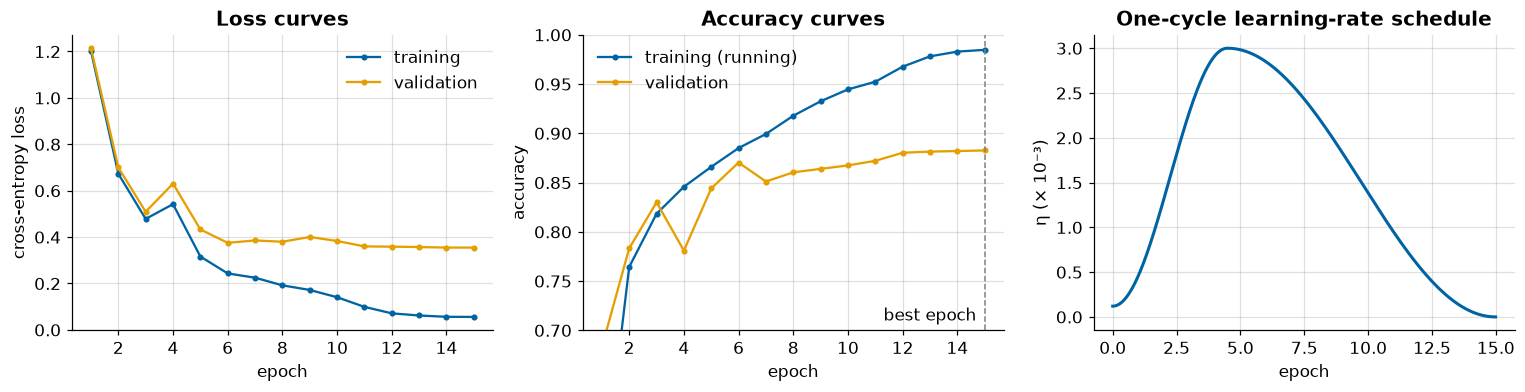

In [8]:
ep = np.arange(1, EPOCHS + 1)
fig, axes = plt.subplots(1, 3, figsize=(14, 3.7))
axes[0].plot(ep, ref["train_eval_loss"], "o-", ms=3, label="training"); axes[0].plot(ep, ref["val_loss"], "o-", ms=3, label="validation")
axes[0].set(xlabel="epoch", ylabel="cross-entropy loss", title="Loss curves")
axes[1].plot(ep, ref["train_acc"], "o-", ms=3, label="training (running)"); axes[1].plot(ep, ref["val_acc"], "o-", ms=3, label="validation")
axes[1].axvline(ref["best_epoch"], color="gray", ls="--", lw=1); axes[1].text(ref["best_epoch"] - 0.3, 0.71, "best epoch", ha="right", fontsize=11)
axes[1].set(xlabel="epoch", ylabel="accuracy", ylim=(0.7, 1.0), title="Accuracy curves")
axes[2].plot(np.arange(len(ref["lr"])) / steps_ep, np.array(ref["lr"]) * 1e3, color=PALETTE[0], lw=2)
axes[2].set(xlabel="epoch", ylabel="η (× 10⁻³)", title="One-cycle learning-rate schedule")
for ax in axes: ax.grid(alpha=0.4)
axes[0].legend(); axes[1].legend(loc="upper left"); plt.tight_layout(); plt.show()

Training accuracy keeps climbing while validation flattens around 88%: a gap of ~10 points. The schedule warms up to η = 3·10⁻³ over the first ~30% of the updates and then anneals to almost zero, which is why the curves settle in the last epochs.

### 5.2 Optimizers: SGD vs momentum vs Adam
Constant step sizes (SGD and momentum η = 0.01, Adam η = 10⁻³ — the usual defaults), **no BatchNorm**, 10 epochs.

SGD             best validation accuracy 75.1%
SGD + momentum  best validation accuracy 84.8%
Adam            best validation accuracy 84.3%


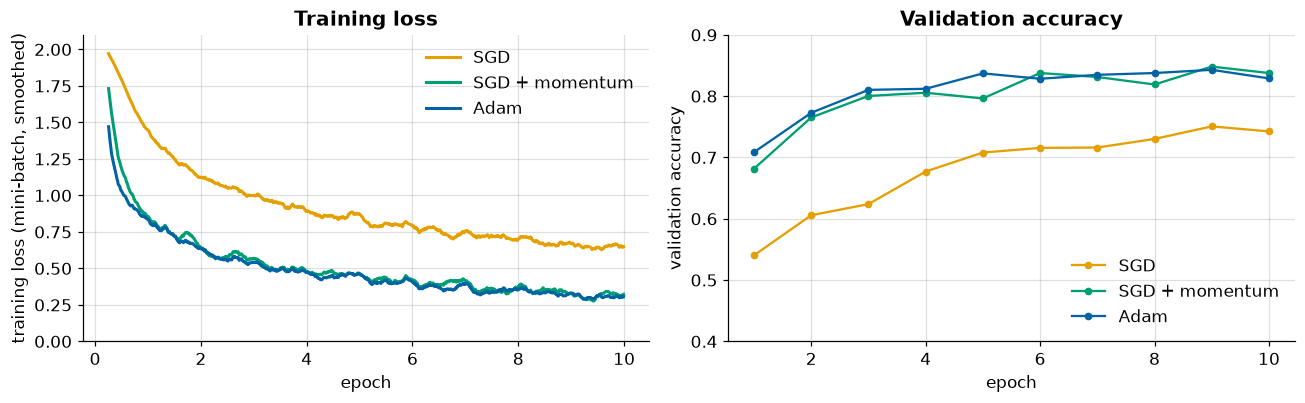

In [9]:
opt_runs = {name: train(opt=o, lr=lr, model_kw=dict(norm=None), sched="const", epochs=10)
            for name, o, lr in [("SGD", "sgd", 0.01), ("SGD + momentum", "momentum", 0.01), ("Adam", "adam", 1e-3)]}

def smooth(v, k=25):
    v = np.asarray(v, float)
    return np.concatenate([np.full(k - 1, np.nan), np.convolve(v, np.ones(k) / k, mode="valid")]) if len(v) >= k else v

fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
for (k, h), col in zip(opt_runs.items(), [PALETTE[1], PALETTE[2], PALETTE[0]]):
    axes[0].plot(np.arange(len(h["step_loss"])) / steps_ep, smooth(h["step_loss"]), color=col, lw=2, label=k)
    axes[1].plot(np.arange(1, 11), h["val_acc"], "o-", ms=4, color=col, label=k)
    print(f"{k:15s} best validation accuracy {pct(best_val(h))}")
axes[0].set(xlabel="epoch", ylabel="training loss (mini-batch, smoothed)", ylim=(0, 2.1), title="Training loss")
axes[1].set(xlabel="epoch", ylabel="validation accuracy", ylim=(0.4, 0.9), title="Validation accuracy")
for ax in axes: ax.grid(alpha=0.4); ax.legend()
plt.tight_layout(); plt.show()

Plain SGD at η = 0.01 is still learning after 10 epochs; momentum accumulates the consistent gradient direction (up to $1/(1-\beta) = 10\times$ the step) and Adam rescales each parameter's step by its gradient history — both get there much faster. With tuned learning rates the gap between the three shrinks; the default step sizes are what make Adam the easy first choice.

### 5.3 Learning-rate sweep (Adam, constant η, no BatchNorm, 10 epochs)

η = 1e-05: best validation accuracy 60.4%
η = 0.0001: best validation accuracy 78.6%
η = 0.001: best validation accuracy 84.3%
η = 0.01: best validation accuracy 81.0%
η = 0.1: best validation accuracy 44.6%
η = 1: diverged in epoch 1 (loss became non-finite / exploded)


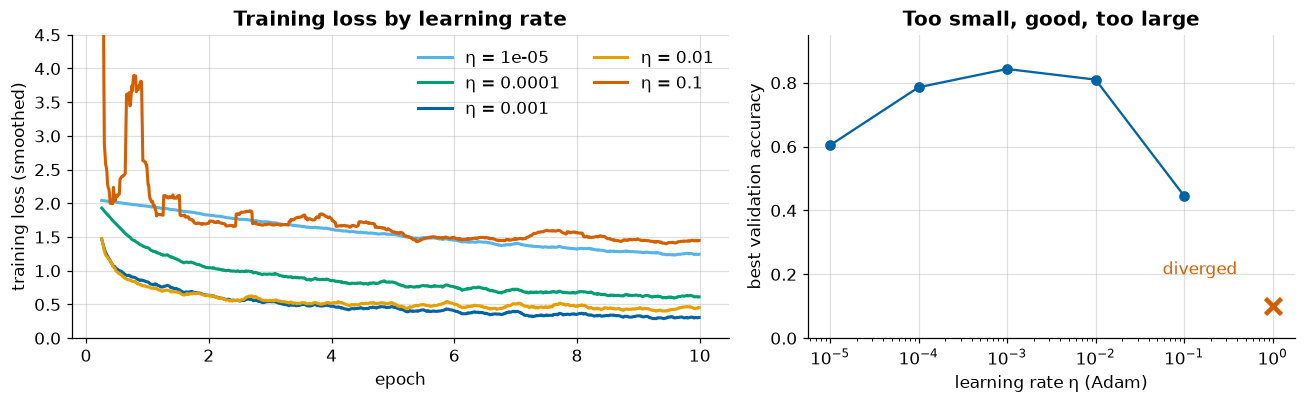

In [10]:
LRS = [1e-5, 1e-4, 1e-3, 1e-2, 1e-1, 1.0]
lr_runs = {lr: train(opt="adam", lr=lr, model_kw=dict(norm=None), sched="const", epochs=10) for lr in LRS}

fig, axes = plt.subplots(1, 2, figsize=(12, 3.8), gridspec_kw=dict(width_ratios=[1.35, 1]))
cols = [PALETTE[4], PALETTE[2], PALETTE[0], PALETTE[1], PALETTE[5], PALETTE[3]]
for (lr, h), col in zip(lr_runs.items(), cols):
    if h.get("diverged_epoch"):
        print(f"η = {lr:g}: diverged in epoch {h['diverged_epoch']} (loss became non-finite / exploded)")
        continue
    axes[0].plot(np.arange(len(h["step_loss"])) / steps_ep, smooth(h["step_loss"]), color=col, lw=2, label=f"η = {lr:g}")
    print(f"η = {lr:g}: best validation accuracy {pct(best_val(h))}")
axes[0].set(xlabel="epoch", ylabel="training loss (smoothed)", ylim=(0, 4.5), title="Training loss by learning rate")
axes[0].legend(ncol=2, fontsize=11)
va = [best_val(lr_runs[lr]) for lr in LRS]
axes[1].semilogx(LRS, va, "o-", color=PALETTE[0])
for lr, v in zip(LRS, va):
    if np.isnan(v):
        axes[1].plot([lr], [0.1], "x", color=PALETTE[5], ms=11, mew=3)
        axes[1].annotate("diverged", (lr, 0.1), (lr * 0.4, 0.2), ha="right", color=PALETTE[5])
axes[1].set(xlabel="learning rate η (Adam)", ylabel="best validation accuracy", ylim=(0, 0.95), title="Too small, good, too large")
for ax in axes: ax.grid(alpha=0.4)
plt.tight_layout(); plt.show()

Too small (10⁻⁵) and the loss is still falling after 10 epochs; 10⁻³ is the sweet spot; at 0.1 the loss spikes and stalls; at η = 1 the very first updates blow up. **Tune η first** — on a log scale — before anything else.

### 5.4 Initialization: why not all zeros?
If every weight starts at the same value, all hidden units in a layer compute the same function and receive the same gradient — they stay identical forever (*symmetry*). With all-zero weights, ReLU hidden units output 0, so no gradient reaches the hidden weights at all and only the output bias learns: the network predicts the majority class. Below, the reference MLP with (a) all weights 0, (b) all weights 0.01 (biases 0), trained for 1 epoch with Adam; (c) default PyTorch (Kaiming-uniform) initialization.

In [11]:
def const_init(value):
    def f(m):
        for mod in m:
            if isinstance(mod, nn.Linear):
                nn.init.constant_(mod.weight, value); nn.init.zeros_(mod.bias)
    return f

prior_val = float((y_va == torch.bincount(y_tr).argmax()).float().mean())
print(f"majority-class baseline on validation: {pct(prior_val)}")
for name, init in [("all zeros", const_init(0.0)), ("all 0.01", const_init(0.01)), ("default", None)]:
    h = train(opt="adam", lr=1e-3, sched="const", epochs=1, init=init)
    W1 = h["model"][1].weight.detach()
    print(f"{name:9s}: validation accuracy after 1 epoch {pct(h['val_acc'][0])};  first-layer rows differ by at most "
          f"{float((W1 - W1[0]).abs().max()):.1g}")

majority-class baseline on validation: 19.5%


all zeros: validation accuracy after 1 epoch 19.5%;  first-layer rows differ by at most 0


all 0.01 : validation accuracy after 1 epoch 31.8%;  first-layer rows differ by at most 0.0004


default  : validation accuracy after 1 epoch 78.6%;  first-layer rows differ by at most 0.1


Zero initialization gets stuck exactly at the majority-class accuracy, and with the constant-0.01 start all 40 first-layer rows stay identical up to floating-point rounding (differences ~10⁻⁴, vs ~0.1 between randomly initialized rows): the network behaves like one with a single hidden unit per layer and learns far less. Random, variance-preserving initialization (He/Kaiming for ReLU: $\mathrm{Var}(W) = 2/d_{\ell-1}$) breaks the symmetry and keeps the signal's scale layer after layer.

### 5.5 Normalization: BatchNorm vs LayerNorm vs none
Left: the reference recipe with each normalization. Right: plain SGD with a far too large step, η = 0.5 (constant, 10 epochs).

Adam one-cycle, BatchNorm        : test accuracy 86.5%
Adam one-cycle, LayerNorm        : test accuracy 84.5%
Adam one-cycle, no normalization : test accuracy 85.4%
SGD η = 0.5,       BatchNorm        : best validation accuracy 83.8%
SGD η = 0.5,       no normalization : best validation accuracy 43.8%


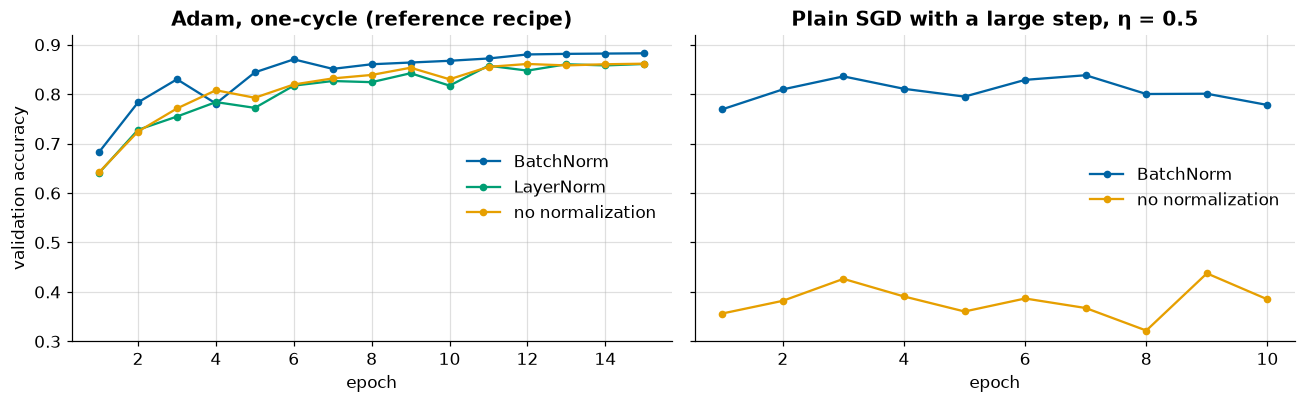

In [12]:
bn_runs = {str(nm): train(model_kw=dict(norm=nm)) for nm in ["bn", "ln", None]}
for nm in ["bn", None]:
    bn_runs[f"sgd_{nm}"] = train(model_kw=dict(norm=nm), opt="sgd", lr=0.5, sched="const", epochs=10)

fig, axes = plt.subplots(1, 2, figsize=(12, 3.8), sharey=True)
for k, lab, col in [("bn", "BatchNorm", PALETTE[0]), ("ln", "LayerNorm", PALETTE[2]), ("None", "no normalization", PALETTE[1])]:
    axes[0].plot(np.arange(1, 16), bn_runs[k]["val_acc"], "o-", ms=4, color=col, label=lab)
    print(f"Adam one-cycle, {lab:17s}: test accuracy {pct(bn_runs[k]['test_acc'])}")
for k, lab, col in [("sgd_bn", "BatchNorm", PALETTE[0]), ("sgd_None", "no normalization", PALETTE[1])]:
    axes[1].plot(np.arange(1, 11), bn_runs[k]["val_acc"], "o-", ms=4, color=col, label=lab)
    print(f"SGD η = 0.5,       {lab:17s}: best validation accuracy {pct(best_val(bn_runs[k]))}")
axes[0].set(title="Adam, one-cycle (reference recipe)", ylabel="validation accuracy")
axes[1].set(title="Plain SGD with a large step, η = 0.5")
for ax in axes: ax.set(xlabel="epoch", ylim=(0.3, 0.92)); ax.grid(alpha=0.4); ax.legend(loc="center right")
plt.tight_layout(); plt.show()

With the well-tuned recipe the three normalizations are within ~2 points (one run each — see the seed spread in §5.8). The large-step SGD run is where BatchNorm shines: the unnormalized network barely learns, the normalized one is fine, because after BN the next layer's input scale no longer depends on the scale of the weights.

**BatchNorm at test time** *(CS284A)*. In `train()` mode BN normalizes with the current batch's mean and variance; in `eval()` mode it uses running averages collected during training. Forgetting `model.eval()` makes each prediction depend on the other cells in the batch:

In [13]:
m_ref = ref["model"]
with torch.no_grad():
    print(f"eval mode (running statistics): {pct((m_ref(X_te).argmax(1) == y_te).float().mean().item())}")
    z = m_ref[1](m_ref[0](X_tr))       # first-layer pre-activations on all training cells
bn1 = m_ref[2]
print(f"running means within {float((bn1.running_mean - z.mean(0)).abs().max()):.2f} of the true training means "
      f"(range ±{float(z.mean(0).abs().max()):.0f}); variances within "
      f"{100 * float((bn1.running_var / z.var(0) - 1).abs().max()):.0f}%")
g = torch.Generator().manual_seed(0)
for B in [2, 8, 32, 256]:
    mm = copy.deepcopy(m_ref).train()
    perm = torch.randperm(len(X_te), generator=g)
    correct = 0
    with torch.no_grad():
        for i in range(0, len(X_te), B):
            idx = perm[i:i + B]
            if len(idx) >= 2:                  # BN cannot normalize a batch of one
                correct += (mm(X_te[idx]).argmax(1) == y_te[idx]).sum().item()
    print(f"train mode, test batches of {B:3d}: {pct(correct / len(X_te))}")

eval mode (running statistics): 86.5%
running means within 0.20 of the true training means (range ±24); variances within 7%


train mode, test batches of   2: 34.0%


train mode, test batches of   8: 74.5%
train mode, test batches of  32: 83.7%
train mode, test batches of 256: 86.3%


### 5.6 Regularization: dropout and weight decay
The reference MLP and recipe with dropout (p = 0.1, 0.3) and/or decoupled weight decay (AdamW, λ = 1), three seeds each, run on the CPU (as in the lecture). *Training* accuracy here is measured in eval mode at the selected epoch; the **gap** is training − best validation accuracy.

In [14]:
REG = {"none": dict(),
       "dropout 0.1": dict(model_kw=dict(p_drop=0.1)),
       "dropout 0.3": dict(model_kw=dict(p_drop=0.3)),
       "weight decay": dict(opt="adamw", wd=1.0),
       "dropout 0.1 + w.d.": dict(opt="adamw", wd=1.0, model_kw=dict(p_drop=0.1))}
SEEDS = [0, 1, 2]
t0 = time.time()
reg_runs = {k: [train(seed=s, device=cpu, **v) for s in SEEDS] for k, v in REG.items()}
print(f"{len(REG) * len(SEEDS)} runs in {time.time() - t0:.0f}s\n")
reg = {}
print(f"{'setting':20s} {'train':>7s} {'val':>7s} {'gap':>6s} {'test':>7s} {'test SD':>8s}")
for k, runs in reg_runs.items():
    tr = np.mean([h["train_eval_acc"][h["best_epoch"] - 1] for h in runs])
    vl = np.mean([best_val(h) for h in runs])
    te = [h["test_acc"] for h in runs]
    reg[k] = dict(train=tr, val=vl, gap=tr - vl, test=np.mean(te), test_sd=np.std(te))
    print(f"{k:20s} {100 * tr:6.1f}% {100 * vl:6.1f}% {100 * (tr - vl):6.1f} {100 * np.mean(te):6.1f}% {100 * np.std(te):7.2f}")

15 runs in 113s

setting                train     val    gap    test  test SD
none                   98.9%   87.8%   11.1   86.8%    0.21
dropout 0.1            96.1%   87.6%    8.5   86.8%    0.48
dropout 0.3            91.0%   86.3%    4.8   85.3%    0.38
weight decay           97.6%   88.6%    9.0   87.2%    0.25
dropout 0.1 + w.d.     95.1%   87.7%    7.4   86.8%    0.19


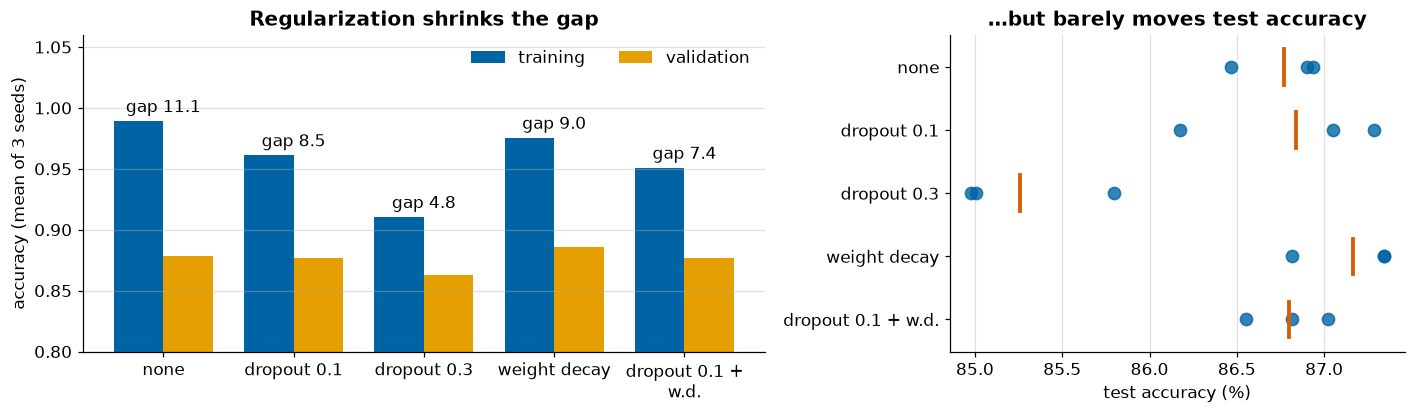

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(13, 3.9), gridspec_kw=dict(width_ratios=[1.5, 1]))
x = np.arange(len(reg)); w = 0.38
axes[0].bar(x - w / 2, [v["train"] for v in reg.values()], w, color=PALETTE[0], label="training")
axes[0].bar(x + w / 2, [v["val"] for v in reg.values()], w, color=PALETTE[1], label="validation")
for i, v in enumerate(reg.values()):
    axes[0].text(i, v["train"] + 0.004, f"gap {100 * v['gap']:.1f}", ha="center", va="bottom", fontsize=11)
axes[0].set_xticks(x, [k.replace(" + ", " +\n") for k in reg], fontsize=11)
axes[0].set(ylim=(0.8, 1.06), ylabel="accuracy (mean of 3 seeds)", title="Regularization shrinks the gap")
axes[0].legend(loc="upper right", ncol=2)
for i, (k, runs) in enumerate(reg_runs.items()):
    te = [100 * h["test_acc"] for h in runs]
    axes[1].plot(te, [i] * len(te), "o", color=PALETTE[0], ms=8, alpha=0.8)
    axes[1].plot([np.mean(te)] * 2, [i - 0.28, i + 0.28], color=PALETTE[5], lw=2.5)
axes[1].set_yticks(range(len(reg)), list(reg)); axes[1].invert_yaxis()
axes[1].set(xlabel="test accuracy (%)", title="…but barely moves test accuracy")
for ax in axes: ax.grid(alpha=0.4, axis="y" if ax is axes[0] else "x")
plt.tight_layout(); plt.show()

Dropout and weight decay close part of the train–validation gap, but test accuracy moves by well under a point — about the size of the seed-to-seed spread. Too much dropout (0.3) on only 40 units underfits. The MLP's limit is its **inductive bias** (a cell shifted by a few pixels is a brand-new input vector), not its variance — that is what the CNN in L09 fixes.

### 5.7 Early stopping on a model that memorizes
To see overfitting clearly, the lecture uses a wider MLP (2352 → 256 → 256 → 8, no BN, 670k parameters) on a **2,000-cell training subset**, constant Adam η = 10⁻³, 60 epochs, and records all epochs (no checkpointing). Early stopping with patience 10 watches the validation loss.

670,216 parameters; final training accuracy 100.0%, training loss 0.0002
validation loss lowest at epoch 8 (0.66), then climbs to 1.15 at epoch 60
patience 10: stop at epoch 18, restore epoch 8 (validation accuracy 76.8% vs 79.4% at epoch 60)


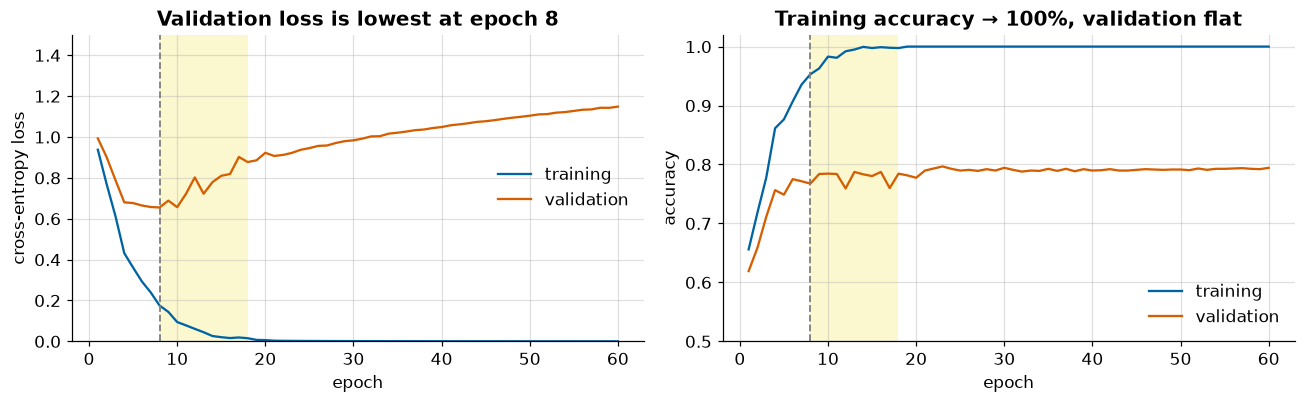

In [16]:
N_SUB, WIDE, PATIENCE = 2000, (256, 256), 10
ov = train(model_kw=dict(widths=WIDE, norm=None), sched="const", epochs=60, n_train=N_SUB, keep_best=False)
vl = np.array(ov["val_loss"]); ov_best = int(np.argmin(vl)) + 1; stop = ov_best + PATIENCE
print(f"{ov['params']:,} parameters; final training accuracy {pct(ov['train_eval_acc'][-1])}, "
      f"training loss {ov['train_eval_loss'][-1]:.4f}")
print(f"validation loss lowest at epoch {ov_best} ({vl[ov_best - 1]:.2f}), then climbs to {vl[-1]:.2f} at epoch 60")
print(f"patience {PATIENCE}: stop at epoch {stop}, restore epoch {ov_best} "
      f"(validation accuracy {pct(ov['val_acc'][ov_best - 1])} vs {pct(ov['val_acc'][-1])} at epoch 60)")

e60 = np.arange(1, 61)
fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
for ax, key, yl, lim in [(axes[0], "loss", "cross-entropy loss", (0, 1.5)), (axes[1], "acc", "accuracy", (0.5, 1.02))]:
    ax.plot(e60, ov[f"train_eval_{key}"], color=PALETTE[0], label="training")
    ax.plot(e60, ov[f"val_{key}"], color=PALETTE[5], label="validation")
    ax.axvline(ov_best, color="gray", ls="--", lw=1.2); ax.axvspan(ov_best, stop, color=PALETTE[6], alpha=0.25, lw=0)
    ax.set(xlabel="epoch", ylabel=yl, ylim=lim); ax.grid(alpha=0.4); ax.legend(loc="center right" if key == "loss" else "lower right")
axes[0].set_title(f"Validation loss is lowest at epoch {ov_best}")
axes[1].set_title("Training accuracy → 100%, validation flat")
plt.tight_layout(); plt.show()

The training loss goes to zero (memorization) while the validation *loss* rises — the model becomes over-confident on the cells it gets wrong — even though validation *accuracy* stays nearly flat (it even creeps up by a couple of points). Early stopping on the validation loss keeps the epoch-8 checkpoint (the best-calibrated model) and saves 40 epochs of compute; if accuracy or macro-F1 is what you care about, monitor that metric instead — the choice of monitored metric is part of the recipe. The reference run above does the same thing on a smaller scale by keeping its best-validation epoch.

### 5.8 Seeds and reproducibility
The same seed on the same machine gives bit-identical weights; different seeds give a spread. Report it before claiming a 1-point improvement.

In [17]:
seed_runs = {0: ref, **{s: train(seed=s) for s in [1, 2]}}
for s, h in seed_runs.items():
    print(f"seed {s}: test accuracy {pct(h['test_acc'])} (best validation epoch {h['best_epoch']})")
te = [h["test_acc"] for h in seed_runs.values()]
print(f"mean ± SD over 3 seeds: {pct(np.mean(te))} ± {100 * np.std(te):.1f}")
rerun = train(seed=0)
same = all(torch.equal(a, b) for a, b in zip(ref["model"].state_dict().values(), rerun["model"].state_dict().values()))
print(f"seed 0 rerun on {dev}: test {pct(rerun['test_acc'])}, identical weights: {same}")

seed 0: test accuracy 86.5% (best validation epoch 15)
seed 1: test accuracy 86.9% (best validation epoch 15)
seed 2: test accuracy 86.9% (best validation epoch 13)
mean ± SD over 3 seeds: 86.8% ± 0.2


seed 0 rerun on cpu: test 86.5%, identical weights: True


On a different device (CPU vs Apple MPS vs CUDA) the same seed gives slightly different numbers, because floating-point operations are summed in a different order. On CUDA, full determinism also needs `torch.use_deterministic_algorithms(True)` and `CUBLAS_WORKSPACE_CONFIG`.

## 6. Evaluation: the reference MLP on the test set

In [18]:
print(classification_report(y_te.numpy(), ref["pred"], target_names=CLASSES, digits=3))

                precision    recall  f1-score   support

      basophil      0.769     0.668     0.715       244
    eosinophil      0.963     0.947     0.955       624
  erythroblast      0.897     0.868     0.882       311
immature gran.      0.705     0.777     0.740       579
    lymphocyte      0.865     0.819     0.841       243
      monocyte      0.740     0.743     0.742       284
    neutrophil      0.907     0.910     0.909       666
      platelet      0.989     0.996     0.993       470

      accuracy                          0.865      3421
     macro avg      0.854     0.841     0.847      3421
  weighted avg      0.867     0.865     0.865      3421



### Numbers on the slides vs this run
The deck's numbers were computed on an Apple-silicon laptop (MPS), except the regularization runs (CPU). On a CPU (or CUDA) most runs differ by a few tenths of a point because of floating-point rounding order; a few fragile settings (Adam at η = 0.1, large-step SGD without BN) differ by more, because they sit at the edge of stability, and the best validation epoch of the reference run can move (13 on MPS, 15 on CPU: the last epochs are within 0.1 point of each other). The table prints both; all conclusions are unchanged.

In [19]:
deck = [  # (quantity, value on the slides, value in this run)
    ("reference: parameters", "96,248", f"{ref['params']:,}"),
    ("reference: training acc. (last epoch)", "98.3%", pct(ref["train_acc"][-1])),
    ("reference: best validation acc. (epoch)", "88.3% (13)", f"{pct(best_val(ref))} ({ref['best_epoch']})"),
    ("reference: test accuracy", "86.67%", f"{100 * ref['test_acc']:.2f}%"),
    ("reference: macro-F1", "0.848", f"{ref['macro_f1']:.3f}"),
    ("optimizers: SGD best val", "75.1%", pct(best_val(opt_runs["SGD"]))),
    ("optimizers: momentum best val", "84.6%", pct(best_val(opt_runs["SGD + momentum"]))),
    ("optimizers: Adam best val", "85.0%", pct(best_val(opt_runs["Adam"]))),
    ("LR sweep η = 1e-5", "60.4%", pct(best_val(lr_runs[1e-5]))),
    ("LR sweep η = 1e-3", "85.0%", pct(best_val(lr_runs[1e-3]))),
    ("LR sweep η = 0.1", "32.5%", pct(best_val(lr_runs[0.1]))),
    ("LR sweep η = 1", "diverged", "diverged" if lr_runs[1.0].get("diverged_epoch") else pct(best_val(lr_runs[1.0]))),
    ("test acc. BatchNorm / none / LayerNorm", "86.7 / 84.8 / 84.5%",
     " / ".join(f"{100 * bn_runs[k]['test_acc']:.1f}" for k in ["bn", "None", "ln"]) + "%"),
    ("SGD η = 0.5 best val, BN / none", "83.6 / 45.4%",
     f"{100 * best_val(bn_runs['sgd_bn']):.1f} / {100 * best_val(bn_runs['sgd_None']):.1f}%"),
    ("seeds 0 / 1 / 2 test acc.", "86.7 / 87.0 / 86.8%", " / ".join(f"{100 * t:.1f}" for t in te) + "%"),
    ("zero init → majority class (val)", "19.5%", pct(prior_val)),
]
print(f"{'quantity':42s} {'slides':>22s} {'this run (' + dev.type + ')':>22s}")
for q, a, b in deck:
    print(f"{q:42s} {a:>22s} {b:>22s}")

quantity                                                   slides         this run (cpu)
reference: parameters                                      96,248                 96,248
reference: training acc. (last epoch)                       98.3%                  98.5%
reference: best validation acc. (epoch)                88.3% (13)             88.3% (15)
reference: test accuracy                                   86.67%                 86.47%
reference: macro-F1                                         0.848                  0.847
optimizers: SGD best val                                    75.1%                  75.1%
optimizers: momentum best val                               84.6%                  84.8%
optimizers: Adam best val                                   85.0%                  84.3%
LR sweep η = 1e-5                                           60.4%                  60.4%
LR sweep η = 1e-3                                           85.0%                  84.3%
LR sweep η = 0.1     

The BatchNorm train-mode accuracies (slides: 86.5 / 74.5 / 35.0% for test batches of 256 / 8 / 2) are printed in §5.5; they depend on the trained reference model, so they shift with it.

## 7. Visualization: what the first layer looks at
Each of the 40 first-layer units has a weight vector in $\mathbb R^{2352}$ — reshaped to 3 × 28 × 28 it is an image "template" the unit correlates with the input.

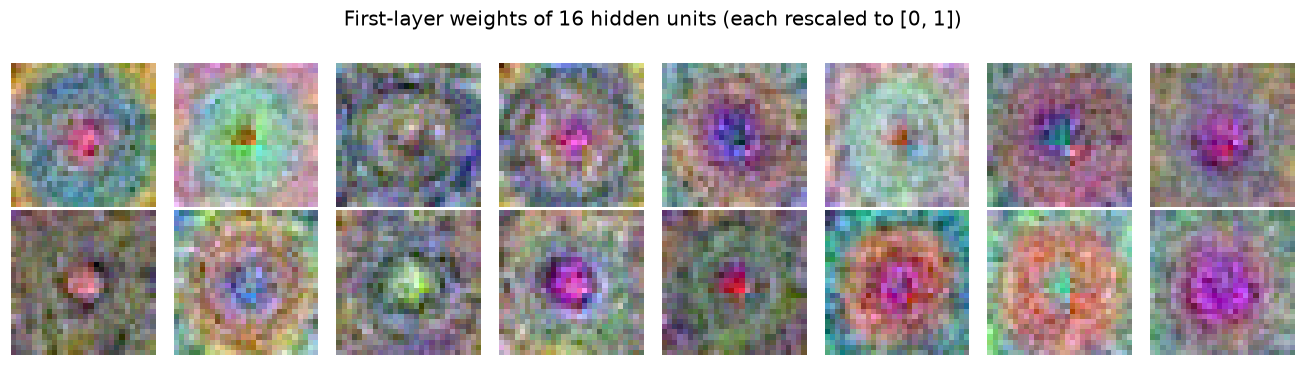

In [20]:
W = ref["model"][1].weight.detach().reshape(40, 3, 28, 28)
fig, axes = plt.subplots(2, 8, figsize=(12, 3.4))
for k, ax in enumerate(axes.ravel()):
    w = W[k].permute(1, 2, 0).numpy()
    ax.imshow((w - w.min()) / (w.max() - w.min() + 1e-9)); ax.axis("off")
plt.suptitle("First-layer weights of 16 hidden units (each rescaled to [0, 1])"); plt.tight_layout(); plt.show()

The templates are centered, roughly radially symmetric blobs and rings — the network has learned "a nucleus of this size and color at the center of the image". Every template is tied to a fixed pixel position, so the MLP must relearn the same pattern at every location; this is the missing prior that convolutions add in L09.

## 8. Biological interpretation

- An MLP on raw 28 × 28 pixels reaches ~87% test accuracy on eight blood-cell types — well above the 19.5% majority baseline, but far from what a hematologist (or the L09 CNN, 95%) achieves. Remaining errors cluster among morphologically similar classes (immature granulocytes vs monocytes/neutrophils — a maturation continuum), where fine chromatin and granule texture matters and is largely lost at 28 px.
- The training "craft" matters a lot for *whether* training works (η, normalization, initialization), and very little for the final accuracy once it does: the best regularizer moved test accuracy by less than one point, the size of the seed-to-seed spread. Always compare methods over several seeds.
- These cells come from healthy donors at one hospital with one stain and one analyzer; no clinical claim follows from these numbers (domain shift — L10).

## Try it yourself

1. **Remove BatchNorm, raise η: when does it break?** Run `train(model_kw=dict(norm=None), opt="sgd", lr=η, sched="const", epochs=10)` for η = 0.05, 0.1, 0.2, 0.5, 1.0 and again with `norm="bn"`. Where does the unnormalized network stop learning, and where does the loss become non-finite (`"diverged_epoch"` in the returned dict)?
2. **Train on 10% of the data: how big is the gap?** `h = train(n_train=len(X_tr) // 10)`, then compare `h["train_eval_acc"][h["best_epoch"] - 1]` with `max(h["val_acc"])` and the test accuracy with the reference run. Add `model_kw=dict(p_drop=0.3)` — does dropout help more with little data?
3. **Batch size:** train with `batch=32` and `batch=1024` (keep the one-cycle schedule). How do the time per epoch and the best validation accuracy change? Why does a larger batch usually need a larger η?
4. **Seeds before conclusions:** rerun the LayerNorm vs BatchNorm comparison of §5.5 with `seed=1` and `seed=2`. Is the difference larger than the seed-to-seed SD?
5. *(CS284A)* **He initialization:** build a 10-layer ReLU MLP of width 256 without normalization, initialize weights as $\mathcal N(0, \sigma^2)$ with σ = 0.01, Xavier $\sqrt{2/(d_{in}+d_{out})}$ and He $\sqrt{2/d_{in}}$, and print the activation SD after each ReLU for a batch of 512 cells. Check the predicted per-layer factor $\sqrt{\tfrac12 \cdot 256\,\sigma^2}$.

In [21]:
print(f"total runtime {time.time() - T_START:.0f}s")

total runtime 232s
